# Commit-level vs. release-level breaking changes

A **commit-level** analysis reports breaking changes between consecutive commits. A
**release-level** analysis reports them between consecutive released versions. The two count
different things, and this notebook measures how differently.

The longitudinal study walks the first-parent history of each library's default branch, ending at
its HEAD. A release-level walk of that same history is the subsequence of those commits that carry
a release tag, diffed consecutively — so the two walks can be compared directly:

| | what it is | step |
|---|---|---|
| **C** | the commit-level walk's breaking changes, summed over the commits between two tags | commit |
| **T** | one Roseau diff between the two tagged commits | tag |

Branch, source roots, exclusion rules, extractor and Roseau build are identical on both sides, so
**granularity is the only variable**. `C ∖ T` is a breaking change the project introduced and then
undid before tagging; `T ∖ C` is one that no single commit pair produced.

Two quantities follow, and they answer different questions:

- **coverage `C∩T / T`** — of what a release-level analysis reports, how much a commit-level
  analysis also finds. This is the question *"does walking commits miss released breaking
  changes?"*
- **survival `C∩T / C`** — of what a commit-level analysis reports, how much is still there at the
  next release. This is the question *"does walking commits over-report?"*

Regenerate with [`benchmark/releases`](../../benchmark/releases/):
`tag_intervals.py` → `run_diffs.sh --tags` → `analyze_tags.py`, checked by `verify_tags.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (12, 6)

# Categorical slots 1-3 of the validated reference palette, used in fixed order.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

coverage = pd.read_csv(DATA_DIR / "tag-coverage.csv").set_index("library")
intervals = pd.read_csv(DATA_DIR / "tag-intervals.csv")
comparison = pd.read_csv(DATA_DIR / "tag-comparison.csv")
fate = pd.read_csv(DATA_DIR / "tag-comparison-fate-by-kind.csv").set_index("kind")
unattributed = pd.read_csv(DATA_DIR / "tag-comparison-unattributed.csv")
comparison_pre = pd.read_csv(DATA_DIR / "tagall-comparison.csv")

usable = comparison[comparison.has_tag_diff]
len(coverage), len(intervals), len(usable)

(29, 1237, 1237)

## 1. Scope: releases tagged on the default branch

Restricting to the default branch is what keeps granularity the only variable, and it has a cost.
A library that cuts its releases on release branches contributes few or no intervals — not because
of a measurement artefact, but because those commits are not part of the history being walked.

In [2]:
cov = coverage.copy()
cov["off_default_branch"] = cov.version_tags_in_repo - cov.tagged_walked_commits
display(cov.sort_values("intervals", ascending=False))

dropouts = cov[cov.intervals <= 2]
display(Markdown(f"""
**{int(cov.tagged_walked_commits.sum())}** stable version tags sit on the walked default branches,
giving **{int(cov.intervals.sum())}** consecutive tag-to-tag intervals over
**{intervals.commits_in_interval.sum():,}** commits.

**{len(dropouts)} of {len(cov)}** libraries contribute two intervals or fewer
({', '.join(dropouts.index)}): they tag their releases on release branches, so a default-branch
walk does not visit them. `mockito-core` alone contributes
{int(cov.loc['mockito-core', 'intervals'])} intervals
({cov.loc['mockito-core', 'intervals'] / cov.intervals.sum():.0%} of the total), which is why every
aggregate below is reported both pooled and as a median over libraries.
"""))

,walked_commits,tags_in_repo,version_tags_in_repo,tagged_walked_commits,intervals,off_default_branch
library,,,,,,
mockito-core,4844,652,651,452,451,199
logback-classic,3888,171,169,83,82,86
joda-time,2178,87,82,75,74,7
testng,3329,107,106,69,68,37
mysql-connector-j,2634,96,96,66,65,30
fastjson,4613,250,250,64,63,186
assertj-core,4263,83,83,61,60,22
lombok,2763,75,74,60,59,14
slf4j-api,1809,104,103,50,49,53



**1264** stable version tags sit on the walked default branches,
giving **1237** consecutive tag-to-tag intervals over
**81,650** commits.

**5 of 29** libraries contribute two intervals or fewer
(commons-beanutils, commons-collections, httpclient, protobuf-java, spring-context): they tag their releases on release branches, so a default-branch
walk does not visit them. `mockito-core` alone contributes
451 intervals
(36% of the total), which is why every
aggregate below is reported both pooled and as a median over libraries.


## 2. Commit-level vs. tag-level

In [3]:
def summarise(df):
    g = df.groupby("library").agg(
        intervals=("pair_id", "size"),
        commits=("commits_in_interval", "sum"),
        C_events=("commit_events", "sum"),
        C=("commit_keys", "sum"),
        T=("tag_keys", "sum"),
        CT=("commit_and_tag", "sum"))
    g = pd.concat([g, g.sum().rename("ALL (pooled)").to_frame().T])
    g["events_per_tag_bc"] = (g.C_events / g["T"]).round(2)
    g["survival_CT_over_C"] = (g.CT / g.C).round(3)
    g["coverage_CT_over_T"] = (g.CT / g["T"]).round(3)
    return g


table = summarise(usable)
display(table)

,intervals,commits,C_events,C,T,CT,events_per_tag_bc,survival_CT_over_C,coverage_CT_over_T
assertj-core,60,3264,14823,4857,4413,4404,3.36,0.907,0.998
commons-codec,3,851,23,14,2,1,11.50,0.071,0.500
commons-collections,2,1654,515,335,14,14,36.79,0.042,1.000
commons-io,8,2850,623,377,26,26,23.96,0.069,1.000
commons-lang,10,3753,353,341,31,31,11.39,0.091,1.000
commons-logging,3,117,0,0,0,0,NaN,NaN,NaN
fastjson,63,4521,1892,1370,1058,1037,1.79,0.757,0.980
gson,25,880,2,2,0,0,inf,0.000,NaN
guava,5,6835,549,502,95,89,5.78,0.177,0.937
h2,19,2087,22469,8725,5867,5725,3.83,0.656,0.976


In [4]:
row = table.loc["ALL (pooled)"]
per_lib = table.drop(index="ALL (pooled)")
display(Markdown(f"""
Over **{len(usable)}** tag-to-tag intervals spanning **{int(row.commits):,}** commits:

- the commit-level walk records **{int(row.C_events):,}** public-API breaking-change events
  (**{int(row.C):,}** distinct);
- a tag-level walk of the same branch finds **{int(row["T"]):,}**;
- **{row.CT / row["T"]:.1%} of the tag-level breaking changes are attributable to a single walked
  commit** (median over libraries {per_lib.coverage_CT_over_T.median():.1%}, median over intervals
  {(usable[usable.tag_keys > 0].commit_and_tag / usable[usable.tag_keys > 0].tag_keys).median():.1%});
- conversely **{row.CT / row.C:.1%}** of the distinct commit-level breaking changes are still there
  at the next tag — but see §3, this number is largely driven by how far apart the tags are.
"""))


Over **1237** tag-to-tag intervals spanning **81,650** commits:

- the commit-level walk records **241,685** public-API breaking-change events
  (**58,587** distinct);
- a tag-level walk of the same branch finds **22,803**;
- **98.2% of the tag-level breaking changes are attributable to a single walked
  commit** (median over libraries 99.2%, median over intervals
  100.0%);
- conversely **38.2%** of the distinct commit-level breaking changes are still there
  at the next tag — but see §3, this number is largely driven by how far apart the tags are.


The two directions answer the two questions asked at the top:

- **Coverage ≈ 98 %.** A commit-level walk is a near-complete *superset* of what a release-level
  walk of the same branch reports: it misses almost nothing, and it additionally localises each
  released breaking change to the commit that introduced it.
- **Survival ≈ 38 %.** The commit-level walk also reports a large amount of intermediate churn that
  the project undoes before tagging. A commit-level count is therefore a count of API-breaking
  *events during development*, not a count of released breaking changes, and must not be presented
  as one.

## 3. Survival is a function of release cadence

The 38 % is not a constant that could be used to convert one count into the other. It depends on
how much development happens between two tags: over a handful of commits a project rarely undoes
what it just did; over hundreds it routinely does.

In [5]:
bins = [0, 10, 30, 100, 300, np.inf]
labels = ["1-10", "11-30", "31-100", "101-300", ">300"]
d = usable[usable.commit_keys > 0].copy()
d["bucket"] = pd.cut(d.commits_in_interval, bins=bins, labels=labels)

by_bucket = d.groupby("bucket", observed=True).agg(
    intervals=("pair_id", "size"),
    C=("commit_keys", "sum"),
    T=("tag_keys", "sum"),
    CT=("commit_and_tag", "sum"))
by_bucket["pooled_survival"] = by_bucket.CT / by_bucket["C"]
by_bucket["median_survival"] = d.groupby("bucket", observed=True).apply(
    lambda g: (g.commit_and_tag / g.commit_keys).median(), include_groups=False)
display(by_bucket.round(3))

,intervals,C,T,CT,pooled_survival,median_survival
bucket,,,,,,
1-10,59,1360,1345,1345,0.989,1.000
11-30,119,2309,1835,1823,0.790,1.000
31-100,169,9211,7143,7061,0.767,0.941
101-300,71,17611,5585,5445,0.309,0.500
>300,54,28096,6895,6712,0.239,0.211


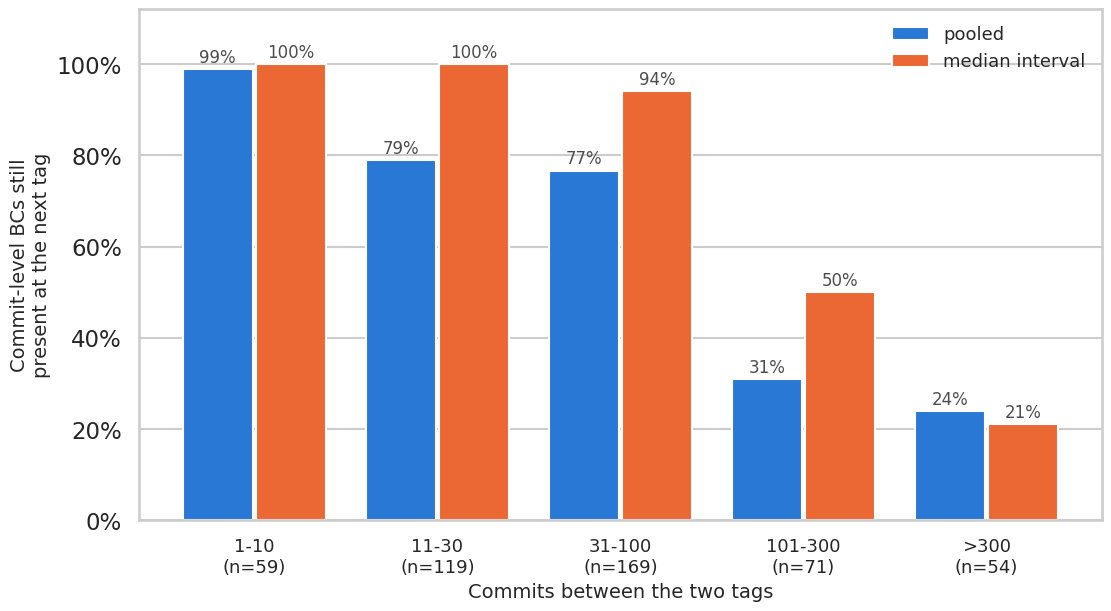

In [6]:
fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
x = np.arange(len(by_bucket))
ax.bar(x - 0.2, by_bucket.pooled_survival, width=0.38, color=BLUE, label="pooled")
ax.bar(x + 0.2, by_bucket.median_survival, width=0.38, color=ORANGE, label="median interval")
for i, (p, m) in enumerate(zip(by_bucket.pooled_survival, by_bucket.median_survival)):
    ax.annotate(f"{p:.0%}", (i - 0.2, p), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=12, color="0.3")
    ax.annotate(f"{m:.0%}", (i + 0.2, m), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=12, color="0.3")
ax.set_xticks(x, [f"{l}\n(n={n})" for l, n in zip(by_bucket.index, by_bucket.intervals)],
              fontsize=13)
ax.set_xlabel("Commits between the two tags", fontsize=14)
ax.set_ylabel("Commit-level BCs still\npresent at the next tag", fontsize=14)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", visible=False)
ax.legend(fontsize=13, frameon=False, loc="upper right")
fig.savefig(FIG_DIR / "survival-vs-cadence.pdf", bbox_inches="tight")
plt.show()

Tight release cadences lose almost nothing: for intervals of ten commits or fewer, 99 % of the
commit-level breaking changes are still there at the next tag. Across intervals longer than 300
commits, only 24 % are. This also explains the gap between the pooled 38 % and the median-interval
94 % in §2 — the pooled figure is dominated by a few very long intervals. The libraries with a low
survival rate there are exactly those whose default branch is tagged rarely (`jackson-databind`:
32 tags over 6,308 commits; `commons-collections`: 2 intervals over 1,654 commits).

## 4. Which kinds of breaking change are undone?

In [7]:
f = fate.copy()
f["total"] = f.sum(axis=1)
f["kept_share"] = (f.kept_at_tag / f.total).round(3)
display(f.sort_values("total", ascending=False).head(12))

,kept_at_tag,undone_before_tag,total,kept_share
kind,,,,
EXECUTABLE_REMOVED,7674,20089,27763,0.276
METHOD_RETURN_TYPE_CHANGED_INCOMPATIBLE,2427,2435,4862,0.499
TYPE_REMOVED,2863,1699,4562,0.628
METHOD_RETURN_TYPE_ERASURE_CHANGED,2161,2295,4456,0.485
METHOD_NOW_FINAL,2348,1973,4321,0.543
FIELD_REMOVED,1644,1174,2818,0.583
TYPE_NEW_ABSTRACT_METHOD,894,1428,2322,0.385
EXECUTABLE_NO_LONGER_THROWS_CHECKED_EXCEPTION,199,2046,2245,0.089
TYPE_SUPERTYPE_REMOVED,422,790,1212,0.348


Deletions are the least durable: only 28 % of the `EXECUTABLE_REMOVED` events recorded commit by
commit are still deletions at the next tag, against 63 % of `TYPE_REMOVED` and 58 % of
`FIELD_REMOVED`. Removing a method and reinstating it (often deprecated) within a release cycle is
routine; removing a whole type is not.

## 5. What the commit-level walk misses

In [8]:
total_t = usable.tag_keys.sum()
missed = unattributed.tag_bcs_not_in_any_commit.sum()
display(Markdown(
    f"**{missed}** of **{total_t:,}** tag-level breaking changes ({missed / total_t:.1%}) match no "
    f"single commit-level breaking change."))

by_lib = (unattributed.groupby("library").tag_bcs_not_in_any_commit.sum()
          .sort_values(ascending=False))
by_kind = (unattributed.groupby("kind").tag_bcs_not_in_any_commit.sum()
           .sort_values(ascending=False))
display(pd.concat([by_lib.head(6).rename("by library"),
                   by_kind.head(6).rename("by kind")], axis=1))

**417** of **22,803** tag-level breaking changes (1.8%) match no single commit-level breaking change.

,by library,by kind
jackson-databind,164.0,NaN
h2,142.0,NaN
mysql-connector-j,37.0,NaN
fastjson,21.0,NaN
joda-time,13.0,NaN
assertj-core,9.0,NaN
EXECUTABLE_REMOVED,NaN,212.0
METHOD_NOW_FINAL,NaN,69.0
METHOD_RETURN_TYPE_CHANGED_INCOMPATIBLE,NaN,46.0
METHOD_RETURN_TYPE_ERASURE_CHANGED,NaN,37.0


These are composite effects over long intervals: a symbol is touched by several commits in a way
that no single commit-pair diff reports under the same `(kind, symbol)` key. In the largest single
contributor — h2 `1.4.200 → 2.0.202`, a major version spanning 388 commits, 129 of the 417 — a
third of the unmatched breaking changes involve a symbol the commit-level walk *did* report on,
under a different kind. Consistent with §3, the residual is concentrated in the longest intervals,
and it bounds what a commit-level analysis can miss at under 2 %.

## 6. Sensitivity: stepping through pre-release tags too

Alphas, betas, RCs and milestones are also points the maintainers labelled on the default branch.
Including them shortens the intervals, brings back two of the libraries that otherwise drop out,
and tests whether the choice of which tags count drives the result.

In [9]:
rows = []
for name, df in [("stable tags only", comparison), ("incl. pre-release tags", comparison_pre)]:
    u = df[df.has_tag_diff]
    g = u.groupby("library").agg(C=("commit_keys", "sum"), T=("tag_keys", "sum"),
                                 CT=("commit_and_tag", "sum"))
    rows.append({
        "variant": name, "libraries": len(g), "intervals": len(u),
        "events per tag-level BC": round(u.commit_events.sum() / u.tag_keys.sum(), 2),
        "survival C∩T/C": round(u.commit_and_tag.sum() / u.commit_keys.sum(), 3),
        "coverage C∩T/T (pooled)": round(u.commit_and_tag.sum() / u.tag_keys.sum(), 3),
        "coverage C∩T/T (median lib)": round((g.CT / g["T"]).median(), 3),
    })
display(pd.DataFrame(rows).set_index("variant"))

,libraries,intervals,events per tag-level BC,survival C∩T/C,coverage C∩T/T (pooled),coverage C∩T/T (median lib)
variant,,,,,,
stable tags only,26,1237,10.6,0.382,0.982,0.992
incl. pre-release tags,28,1586,9.8,0.400,0.979,0.992


The picture is unchanged: coverage stays at ~98 % pooled and 99 % median, and survival moves by
under two points.

**In summary.** A commit-level walk of a default branch recovers 98 % of the breaking changes a
release-level walk of that same branch reports, and attributes each to the commit that introduced
it. It also reports 2.6× as many distinct breaking changes overall, because a majority of what is
broken during a release cycle is repaired before the release — a proportion that grows with the
length of the cycle, from 1 % over ten commits to 76 % over three hundred. The two are therefore
complementary rather than interchangeable, and a commit-level count should be reported as
API-breaking events during development.